# Step 3 — SpatioType assignment on TCGA

Hierarchically clusters TCGA-BRCA patients on their 11-cluster composition vectors, picks the
number of SpatioTypes by three internal validity criteria (elbow, Davies–Bouldin, PAC),
and validates the resulting groups against disease-free survival.

The clustering parameters and validity-metric code live in `../lib/clustering_helpers.py`.

**Inputs (committed under `clustering/data/`)**
- `cluster_props_TCGA.csv` — one row per TCGA patient; 11 columns of `Cluster N` proportions plus survival fields.

**Outputs (committed under `clustering/data/`)**
- `cluster_validity_metrics.csv` — k versus WSS, Davies–Bouldin, PAC.
- `spatiotypes_TCGA_k5.csv` — the input plus assigned `Metacluster` (1…5) and `SpatioType` columns.

## Setup

In [1]:
import sys
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from clustering_helpers import (
    compute_validity_metrics,
    assign_spatiotypes,
    scale_features,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load patient × cluster composition

In [2]:
df = pd.read_csv("../data/cluster_props_TCGA.csv", index_col=0)
cluster_cols = [f"Cluster {i}" for i in range(1, 12)]
X = scale_features(df[cluster_cols].values)
df.shape, X.shape

((858, 30), (858, 11))

## Choose k by three internal validity criteria

The number of SpatioTypes is selected jointly from:

- **WSS (elbow)** — within-cluster sum of squares; we look for the kink.
- **Davies–Bouldin** — lower is better.
- **PAC** — Proportion of Ambiguous Clustering on a subsampled consensus matrix; lower means more stable.

All three computed in `compute_validity_metrics()`.

In [3]:
metrics = compute_validity_metrics(X, ks=range(2, 11))
metrics.to_csv("../data/cluster_validity_metrics.csv", index=False)
metrics

,k,WSS,DB,PAC
0,2,8413.862528,1.368169,0.444590
1,3,7477.082919,1.829906,0.440459
2,4,6606.932173,1.308240,0.552388
3,5,5784.331313,1.074622,0.482580
4,6,5014.450678,1.215901,0.360424
5,7,4418.296134,1.100699,0.356320
6,8,3869.596478,1.059661,0.333176
7,9,3355.380443,1.009144,0.289654
8,10,2844.770050,0.964597,0.226570


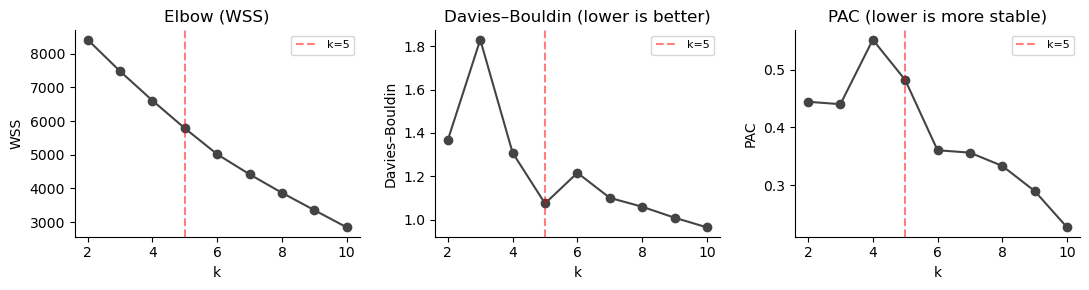

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, col, ylabel, title in zip(
    axes,
    ["WSS", "DB", "PAC"],
    ["WSS", "Davies–Bouldin", "PAC"],
    ["Elbow (WSS)", "Davies–Bouldin (lower is better)", "PAC (lower is more stable)"],
):
    ax.plot(metrics["k"], metrics[col], marker="o", color="#444")
    ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="k=5")
    ax.set(xlabel="k", ylabel=ylabel, title=title)
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

**Choice: k = 5.**
- WSS bends around 5.
- Davies–Bouldin reaches its first local minimum at 5 (1.075).
- PAC is comparable to neighbouring k values without the drop that would indicate over-fitting.

Two of the five resulting Metaclusters end up with only 11 and 5 patients respectively,
which are too small for survival analysis on their own. We retain all five in the heatmap
for completeness and restrict the survival comparison to the three large groups.

## Assign SpatioTypes

In [5]:
sp = assign_spatiotypes(X, reference_k3_labels=df["Metacluster"].values)
df = df.assign(Metacluster_k5=sp["Metacluster"].values, SpatioType=sp["SpatioType"].values)
df[["Metacluster_k5", "SpatioType"]].value_counts().sort_index()

Metacluster_k5  SpatioType            
1               Immune-Inactive            62
2               Metacluster (n=11)         11
3               Immune-Modulated          562
4               Metacluster (n=5)           5
5               Proliferation-Enriched    218
Name: count, dtype: int64

In [6]:
out = df[["tissue_submitter_id"] + cluster_cols + ["DFI", "DFI.time", "OS", "OS.time", "Metacluster_k5", "SpatioType"]]
out.to_csv("../data/spatiotypes_TCGA_k5.csv")
out.head()

,tissue_submitter_id,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,DFI,DFI.time,OS,OS.time,Metacluster_k5,SpatioType
TCGA-3C-AALI-01,TCGA-3C-AALI-01,0.606562,0.000000,0.0,0.000000,0.031638,0.076303,0.000000,0.114846,0.000000,0.170652,0.0,0,133.500000,0,4005,3,Immune-Modulated
TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,0.053905,0.511493,0.0,0.025371,0.000000,0.000000,0.000000,0.138740,0.000000,0.270491,0.0,0,49.133333,0,1474,5,Proliferation-Enriched
TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,11.600000,0,348,3,Immune-Modulated
TCGA-A1-A0SB-01,TCGA-A1-A0SB-01,0.000000,0.000000,0.0,0.313685,0.080537,0.000000,0.065071,0.240152,0.300554,0.000000,0.0,0,8.633333,0,259,5,Proliferation-Enriched
TCGA-A1-A0SD-01,TCGA-A1-A0SD-01,0.000000,0.770007,0.0,0.084580,0.076773,0.013988,0.000000,0.054652,0.000000,0.000000,0.0,0,14.566667,0,437,5,Proliferation-Enriched


## Heatmap of cluster proportions, annotated by SpatioType

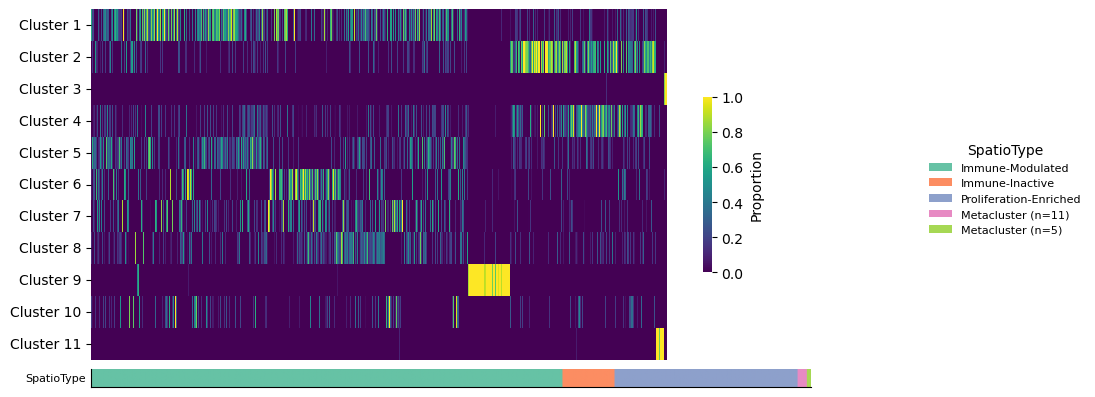

In [7]:
# Order rows by SpatioType for the heatmap
order = df.sort_values(["SpatioType", "Metacluster_k5"]).index
heat = df.loc[order, cluster_cols].values
row_anno = df.loc[order, "SpatioType"].values

fig = plt.figure(figsize=(10, 4.5))
ax_h = fig.add_axes([0.18, 0.12, 0.72, 0.78])
sns.heatmap(
    heat.T,
    cmap="viridis",
    cbar_kws={"label": "Proportion", "shrink": 0.5},
    xticklabels=False,
    yticklabels=cluster_cols,
    ax=ax_h,
)

# annotation bar
ax_anno = fig.add_axes([0.18, 0.06, 0.72, 0.04], sharex=ax_h)
unique_st = list(dict.fromkeys(row_anno))
palette   = sns.color_palette("Set2", n_colors=len(unique_st))
st_to_col = dict(zip(unique_st, palette))
ax_anno.imshow(np.array([list(st_to_col[s]) + [1.0] for s in row_anno])[None, :, :], aspect="auto")
ax_anno.set_xticks([]); ax_anno.set_yticks([])
ax_anno.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=8)

import matplotlib.patches as mp
fig.legend(
    handles=[mp.Patch(facecolor=st_to_col[s], label=s) for s in unique_st],
    loc="center right", bbox_to_anchor=(1.18, 0.5),
    fontsize=8, frameon=False, title="SpatioType",
)
plt.show()

## Disease-free survival by SpatioType (3 main groups)

The two small Metaclusters (n=11 and n=5) are excluded from the survival comparison since
their sample sizes are insufficient for stable Kaplan–Meier estimation.

In [8]:
main = df[df["SpatioType"].isin(["Immune-Modulated", "Immune-Inactive", "Proliferation-Enriched"])].copy()
main = main.dropna(subset=["DFI", "DFI.time"])
main["DFI"] = main["DFI"].astype(float)
main["DFI.time"] = main["DFI.time"].astype(float)
main["SpatioType"].value_counts()

SpatioType
Immune-Modulated          562
Proliferation-Enriched    218
Immune-Inactive            62
Metacluster (n=11)          0
Metacluster (n=5)           0
Name: count, dtype: int64

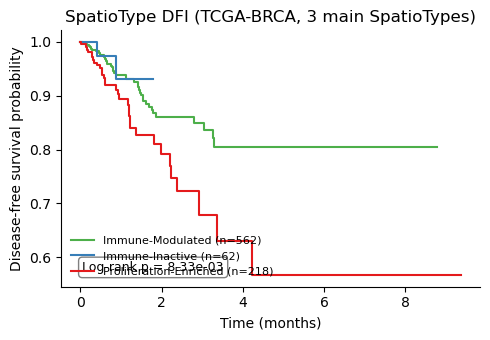

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = {"Immune-Modulated": "#4DAF4A", "Immune-Inactive": "#377EB8", "Proliferation-Enriched": "#E41A1C"}
for st in ["Immune-Modulated", "Immune-Inactive", "Proliferation-Enriched"]:
    g = main[main["SpatioType"] == st]
    KaplanMeierFitter().fit(
        durations=g["DFI.time"] / 30.44, event_observed=g["DFI"],
        label=f"{st} (n={len(g)})",
    ).plot_survival_function(ax=ax, color=colors[st], linewidth=1.5, ci_show=False)

p = multivariate_logrank_test(main["DFI.time"], main["SpatioType"], main["DFI"]).p_value
ax.text(0.05, 0.05, f"Log-rank p = {p:.2e}", transform=ax.transAxes,
        fontsize=9, va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))
ax.set(xlabel="Time (months)", ylabel="Disease-free survival probability",
       title="SpatioType DFI (TCGA-BRCA, 3 main SpatioTypes)")
ax.legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

In [10]:
pairwise = pairwise_logrank_test(main["DFI.time"], main["SpatioType"], main["DFI"])
pairwise.summary

test_statistic         p  -log2(p)
Immune-Inactive  Immune-Modulated              0.075727  0.783173  0.352596
                 Proliferation-Enriched        1.453609  0.227950  2.133212
Immune-Modulated Proliferation-Enriched        9.073103  0.002594  8.590625